## Diffeomorphic Bases

Here, we will experiment with the idea of transforming bases using the half-density idea and normalizing flows. First off, get the imports out of the way!

In [96]:
import torch
import numpy as np
import math

## An Example Dataset

The following is an example dataset:

In [97]:
import torch

def random_bandpass_field(xy, seed, f_lo, f_hi, n_waves=256):
    """
    Vectorized evaluation of a random band-pass 2D field at given coordinates.

    Parameters
    ----------
    xy : array-like, shape (N, 2)
        Coordinates in [0,1]^2 where the field is evaluated.
    seed : int
        Random seed that determines the random function.
    f_lo, f_hi : float
        Lower/upper bounds of the spatial frequency *band* (cycles per unit).
        Must satisfy 0 <= f_lo < f_hi.
    n_waves : int, optional
        Number of random plane waves to mix (controls texture/variance).

    Returns
    -------
    y : np.ndarray, shape (N,)
        Field values at each input coordinate.
    """
    xy = torch.asarray(xy)
    if xy.ndim != 2 or xy.shape[1] != 2:
        raise ValueError("xy must have shape (N, 2)")
    if not (0.0 <= f_lo < f_hi):
        raise ValueError("Require 0 <= f_lo < f_hi")

    rng = torch.Generator().manual_seed(seed)

    # Random directions on the unit circle
    theta = torch.rand(size=(n_waves,), generator=rng) * 2.0 * torch.pi
    dirs = torch.column_stack((torch.cos(theta), torch.sin(theta)))  # (M,2)

    # Sample frequencies with density ∝ r so that wavevectors are ~uniform over the annulus area
    # Equivalent to sampling r^2 uniformly in [f_lo^2, f_hi^2].
    r2 = torch.rand(size=(n_waves,), generator=rng) * (f_hi*f_hi - f_lo*f_lo) + f_lo*f_lo
    r = torch.sqrt(r2)  # (M,)
    k = dirs * r[:, None]  # (M,2) wavevectors

    # Random phases and weights
    # phi = torch.rand(size=(n_waves,), generator=rng) * 2.0 * torch.pi            # (M,)
    weights = torch.randn(size=(n_waves,), generator=rng) / math.sqrt(n_waves)  # (M,)

    # Evaluate: sum_j w_j * cos(2π * <k_j, x> + φ_j)
    # phase = 2.0*torch.pi * (xy @ k.T) + phi  # (N,M)
    # y = (weights * torch.cos(phase)).sum(axis=1)  # (N,)

    y = (weights * torch.cos(xy @ k.T)).sum(axis=1)  # (N,)
    return y


View some of the random bandpass fields that are obtained:

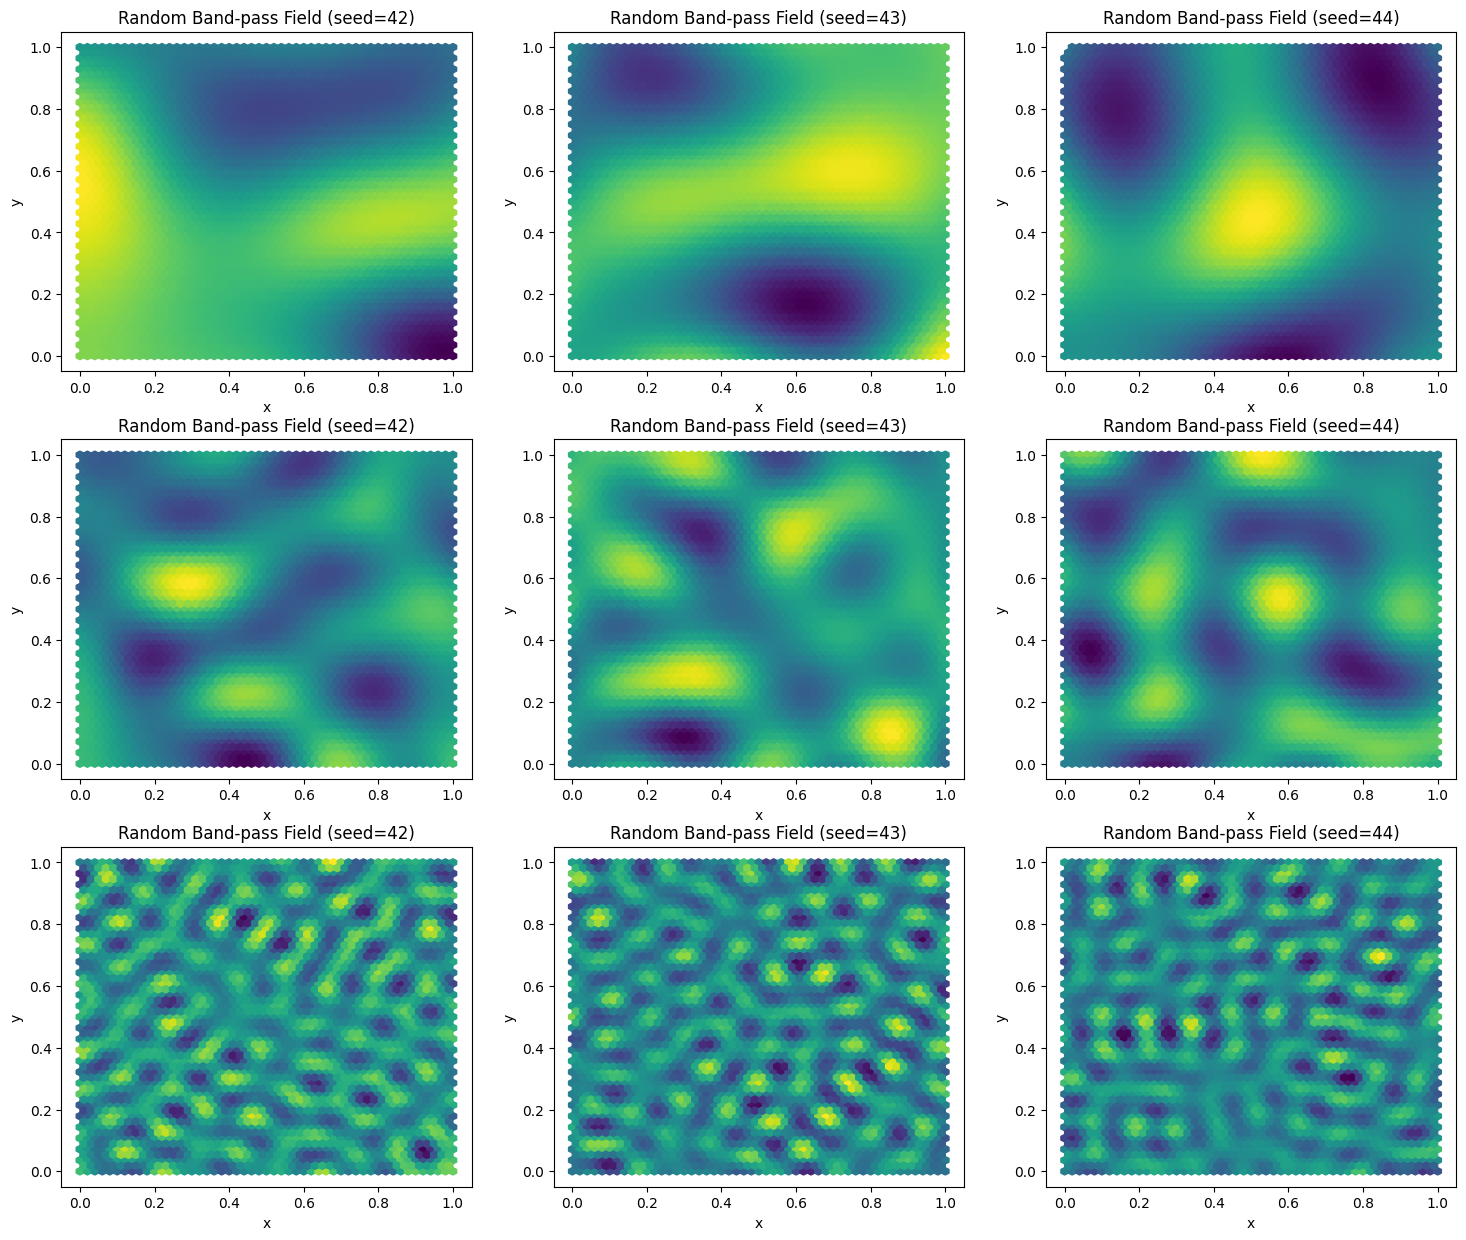

In [98]:
import matplotlib.pyplot as plt
# Example
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
N = 5000_0

for row_idx, f_range in enumerate([(1.0, 10.0), (10.0, 20.0), (50.0, 60.0)]):
    f_lo, f_hi = f_range
    for col_idx, seed in enumerate([42, 43, 44]):
        ax = axes[row_idx, col_idx]
        xy = torch.rand(N, 2)
        vals = random_bandpass_field(xy, seed=seed, f_lo=f_lo, f_hi=f_hi, n_waves=256)  # shape (N,)
        ax.hexbin(xy[:,0], xy[:,1], C=vals, gridsize=50, cmap='viridis') 
        ax.set_title(f'Random Band-pass Field (seed={seed})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')


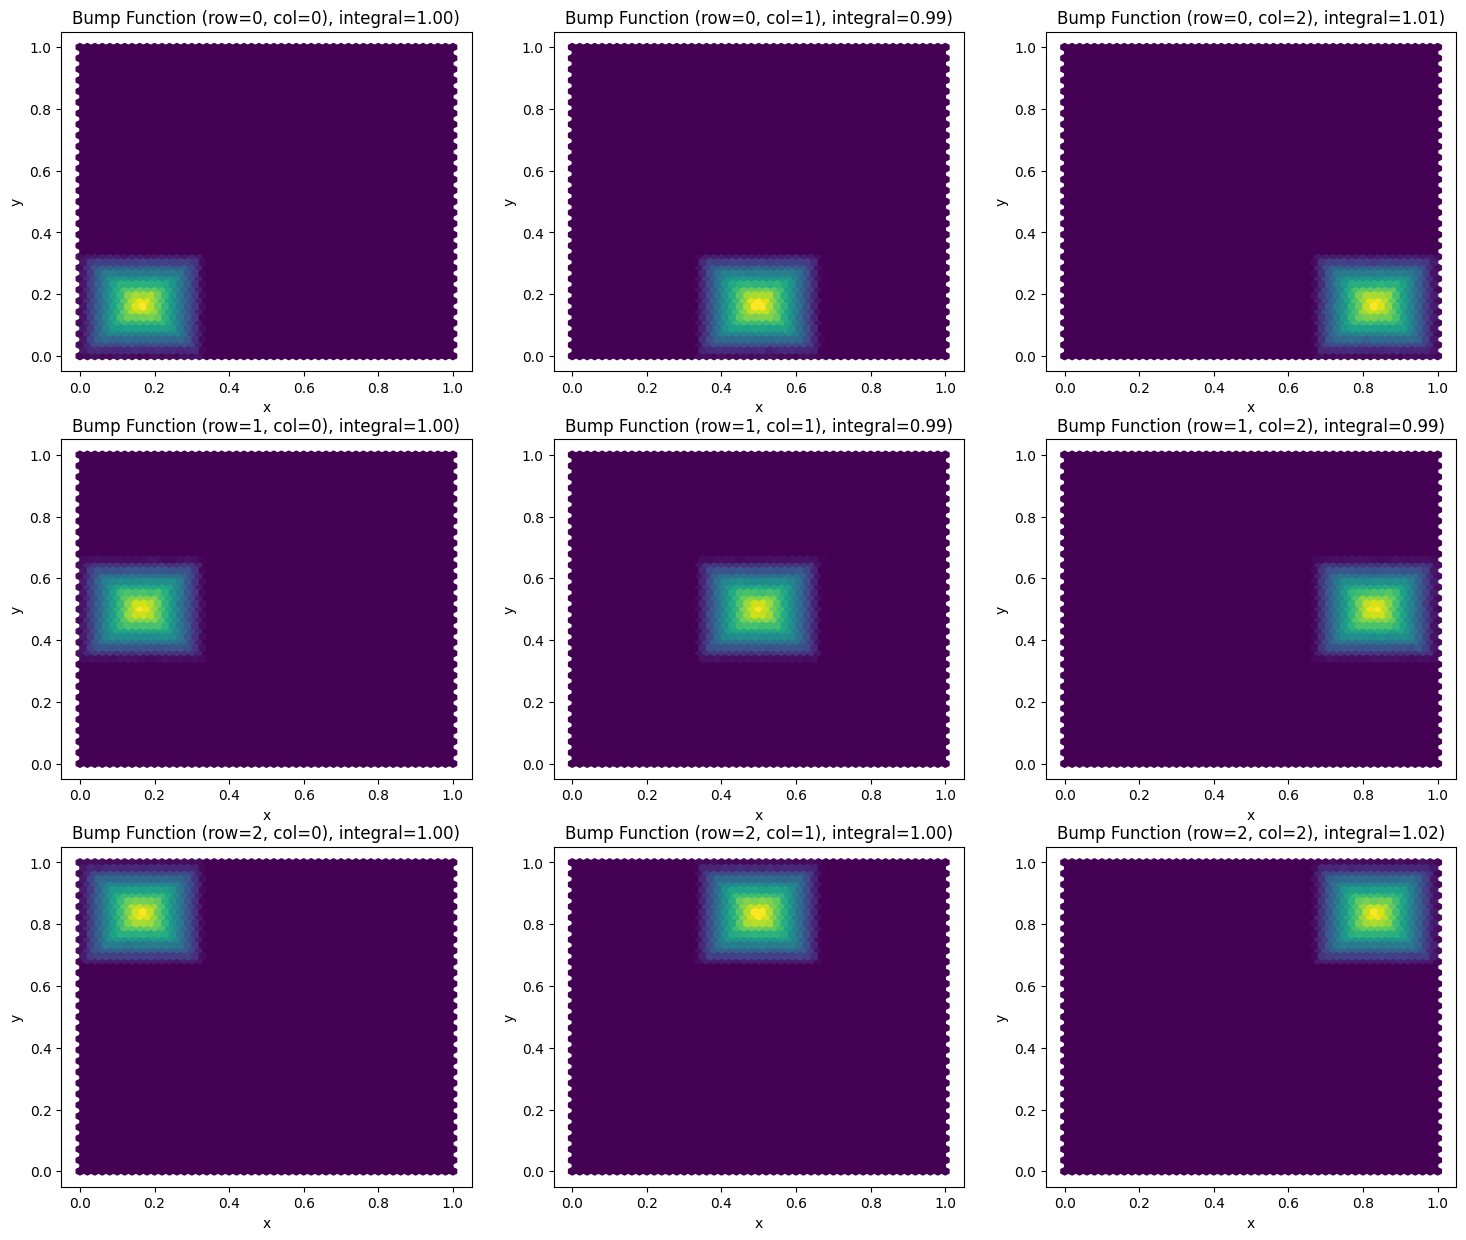

In [99]:

def tent_basis_2d(xy, row, col, total_rows, total_cols,
                  normalize="l2",  # 'l1' for ∫f=1, 'l2' for ‖f‖₂=1, or None
                  dtype=torch.float32):
    xy = torch.as_tensor(xy, dtype=dtype)

    w = 1.0 / float(total_cols)
    h = 1.0 / float(total_rows)
    xc = (col + 0.5) * w
    yc = (row + 0.5) * h

    u = torch.abs(xy[:, 0] - xc) / (0.5 * w)
    v = torch.abs(xy[:, 1] - yc) / (0.5 * h)
    tent = torch.clamp(1.0 - torch.maximum(u, v), min=0.0)

    if normalize is None:
        scale = 1.0
    elif normalize.lower() in ("l1", "integral"):
        scale = 3.0 / (w * h)                     # ∫ f = 1
    elif normalize.lower() in ("l2",):
        scale = math.sqrt(6.0 / (w * h))          # ‖f‖₂ = 1
    else:
        raise ValueError("normalize must be one of {'l1','l2',None}")

    return tent * scale



# visualize bumps
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
N = 5000_0
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        xy = torch.rand(N, 2)
        vals = tent_basis_2d(xy, row, col, total_rows=3, total_cols=3)
        # approximate integral by monte carlo
        integr = torch.sqrt((vals * vals).mean()).item()  # should be close to zero
        ax.hexbin(xy[:,0], xy[:,1], C=vals, gridsize=50, cmap='viridis') 
        ax.set_title(f'Bump Function (row={row}, col={col}), integral={integr:.2f})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    

## Deformed Basis

Create a diffeomorphism using `nflows` library that maps from $[0, 1]^2 \to [0, 1]^2$.

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn

from nflows.transforms import Transform, CompositeTransform, Sigmoid, IdentityTransform, PiecewiseRationalQuadraticCouplingTransform, ActNorm
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform as MAF
from nflows.transforms.permutations import RandomPermutation
from nflows.nn.nets import ResidualNet

class LogitTransform(Transform):
    def __init__(self, alpha=0.05, eps=1e-7):
        super().__init__()
        if alpha <= eps or alpha >= 0.5:
            raise ValueError("alpha must be in (eps, 0.5).")
        self.alpha = alpha
        self.eps = eps

    @staticmethod
    def _stable_logit(x):
        # log(x) - log1p(-x) is a stable logit when x∈(0,1)
        return torch.log(x) - torch.log1p(-x)

    def forward(self, inputs, context=None):
        dims = list(range(1, inputs.ndim))
        # Map [0,1] → [α, 1−α]
        pre_logit = self.alpha + (1.0 - 2.0*self.alpha) * inputs
        pre_logit = pre_logit.clamp(self.eps, 1.0 - self.eps)

        y = self._stable_logit(pre_logit)

        # ldj = sum_j [ log(1-2α) - log(pre_logit_j) - log(1-pre_logit_j) ]
        logdets = torch.sum(
            math.log(1.0 - 2.0*self.alpha)
            - torch.log(pre_logit)
            - torch.log1p(-pre_logit),
            dim=dims
        )
        return y, logdets

    def inverse(self, inputs, context=None):
        dims = list(range(1, inputs.ndim))
        sigm = torch.sigmoid(inputs)                       # (0,1)
        sigm = sigm.clamp(self.eps, 1.0 - self.eps)
        x = (sigm - self.alpha) / (1.0 - 2.0*self.alpha)
        x = x.clamp(self.eps, 1.0 - self.eps)

        logdets = torch.sum(
            torch.log(sigm) + torch.log1p(-sigm) - math.log(1.0 - 2.0*self.alpha),
            dim=dims
        )
        return x, logdets

def build_flow_Rd(d, hidden_features=64, num_layers=5, num_blocks=2):
    layers = []
    for i in range(num_layers):
        layers.append(
            PiecewiseRationalQuadraticCouplingTransform(
                mask=((torch.arange(d) + i) % 2 == 0),
                transform_net_create_fn=lambda in_features, out_features: ResidualNet(
                    in_features=in_features,
                    out_features=out_features,
                    hidden_features=hidden_features,
                    num_blocks=num_blocks
                ),
                tails='linear',        # <-- avoids inputOutsideDomain
                tail_bound=5.0,        # widen if needed
                num_bins=8,
                min_bin_width=1e-3,
                min_bin_height=1e-3
            )
        )
    return CompositeTransform(layers)


def build_unitcube_diffeo(d, hidden_features=64, num_layers=5, num_blocks=2, eps=1e-7):
    """
    Diffeomorphism on (0,1)^d constructed as sigmoid ∘ F ∘ logit.
    """
    flow_Rd = build_flow_Rd(d, hidden_features, num_layers, num_blocks)

    # In nflows, Sigmoid() maps R^d -> (0,1)^d; its inverse is Logit.
    logit = LogitTransform(eps=eps)
    sigmoid = Sigmoid()

    # Optional clamp to avoid 0/1 before logit
    return CompositeTransform([
        # ActNorm(features=d),
        logit,                   # -> R^d
        flow_Rd,                 # -> R^d
        sigmoid                  # -> (0,1)^d
    ])


In [108]:

d = 2
T = build_unitcube_diffeo(d, hidden_features=2, num_layers=2, num_blocks=2, eps=1e-7)

# Sample some points in (0,1)^d
x = torch.rand(8, d)

# Forward map and determinant of Jacobian
y, detJ = T(x, context=None)
print("y in (0,1)^d:", y.min().item(), y.max().item())
print("det J_T(x):", detJ)

# Inverse consistency check
x_rec, detJ_inv = T.inverse(y, context=None)
print("max |x - T^{-1}(T(x))|:", (x - x_rec).abs().max().item())
# Sanity: det(T) * det(T^{-1}) = 1 (up to numerical error)
print("max |detJ * detJ_inv - 1|:", (torch.exp(detJ + detJ_inv) - 1).abs().max().item())

y in (0,1)^d: 0.1019737645983696 0.9663795232772827
det J_T(x): tensor([-2.3772, -3.3427, -1.0136,  0.8142, -0.9869,  0.0222,  0.2686, -3.2119],
       grad_fn=<AddBackward0>)
max |x - T^{-1}(T(x))|: 2.4437904357910156e-06
max |detJ * detJ_inv - 1|: 1.239776611328125e-05


0.020117534324526787 0.9908834099769592
0.020053938031196594 0.9909206628799438
0.020013758912682533 0.9908725619316101
0.020114384591579437 0.9909369349479675
0.020124725997447968 0.990912914276123
0.020125925540924072 0.9909133911132812
0.020189383998513222 0.9909229874610901
0.020047416910529137 0.9909138679504395
0.020028717815876007 0.9909186363220215


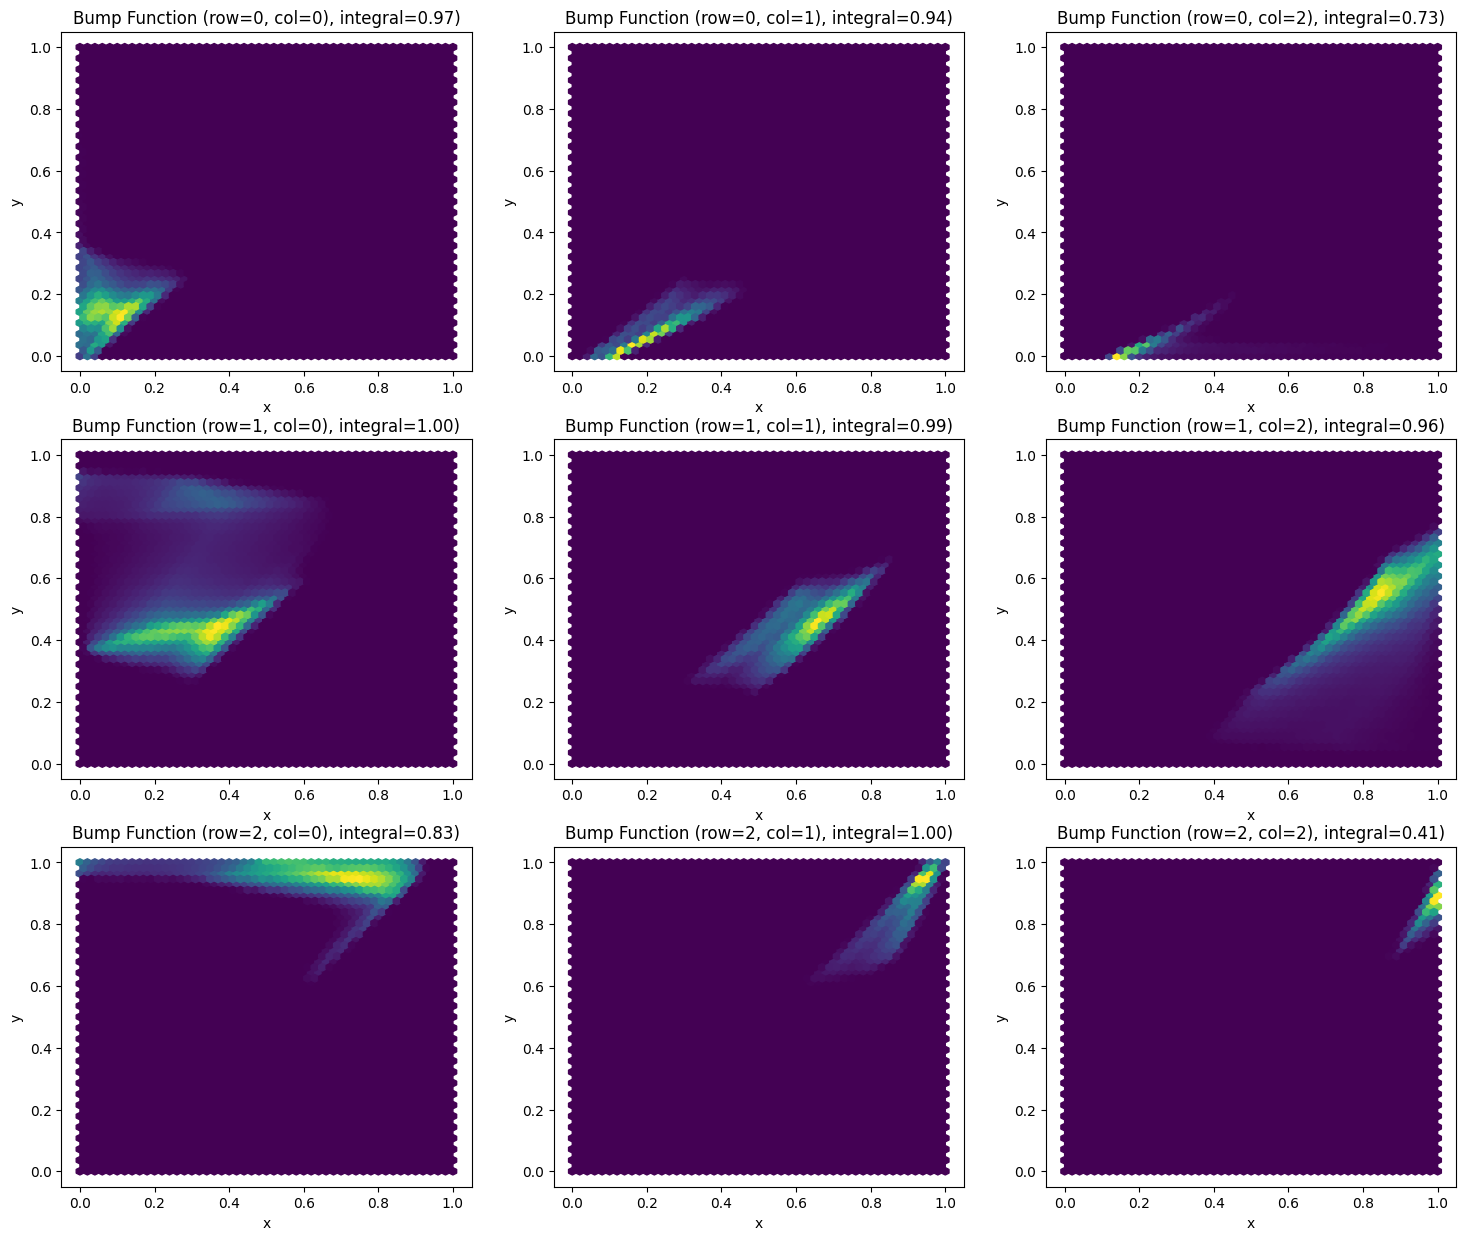

In [109]:

def deformed_basis(xy, row, col, total_rows, total_cols, transform, basis_fn):
    transformed_xy, logabsdet = transform(xy, context=None)
    print(transformed_xy.min().item(), transformed_xy.max().item())
    basis_fn_vals = basis_fn(transformed_xy, row, col, total_rows, total_cols)
    return basis_fn_vals * torch.exp(0.5 * logabsdet)

# visualize bumps
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
N = 5000_0
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        xy = torch.rand(N, 2)
        vals = deformed_basis(xy, row, col, total_rows=3, total_cols=3, transform=T, basis_fn=tent_basis_2d).detach()
        # approximate integral by monte carlo
        integr = torch.sqrt((vals * vals).mean()).item()  # should be close to zero
        ax.hexbin(xy[:,0], xy[:,1], C=vals, gridsize=50, cmap='viridis') 
        ax.set_title(f'Bump Function (row={row}, col={col}), integral={integr:.2f})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    

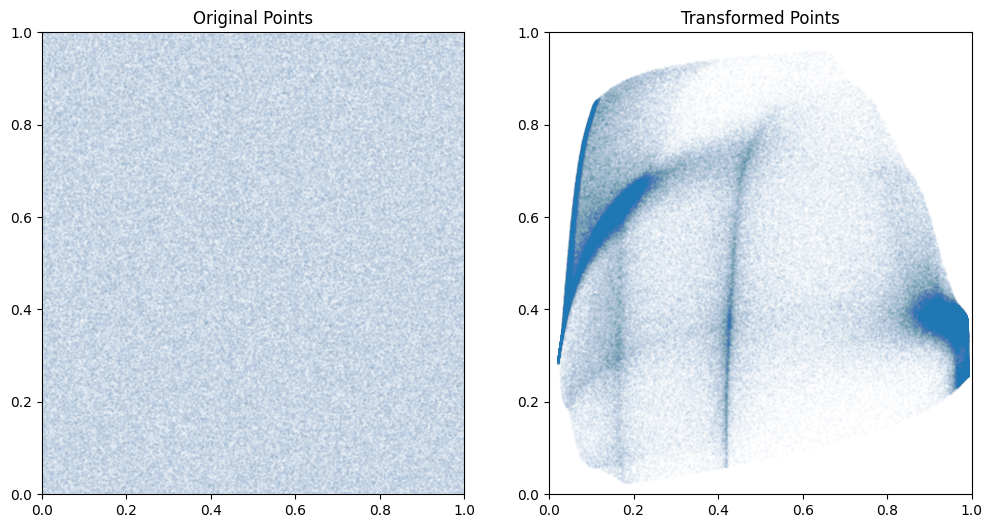

In [114]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
xy = torch.rand(N * 10, 2)
ax[0].scatter(xy[:,0], xy[:,1], s=1, alpha=0.01)
ax[0].set_xlim(0,1)
ax[0].set_ylim(0,1)
ax[0].set_title('Original Points')
transformed_xy, logabsdet = T(xy, context=None)
transformed_xy = transformed_xy.detach().cpu().numpy()
ax[1].scatter(transformed_xy[:,0], transformed_xy[:,1], s=1, alpha=0.01)
ax[1].set_xlim(0,1)
ax[1].set_ylim(0,1)
ax[1].set_title('Transformed Points')
plt.show()